##  Modulus grids

The notion of a **modulus grid** is best illustarted with a picture.  Modulus grids are grids of integers
colored by residue class.  Typically the parameters that matter for the icture are the column width of the grid,
the modulus, and the step size.  To begin with consider an arithmetic series with a step size of one.
Now arrange the series in an r x c array.  Next color the nunbers by their residue class with respect to
modulus m. So for example, when the modulus is 3, there are 3 residue classes corresponding to the possible remainders when dividing integers by 3: 0, 1, and 2. If the array is 4x4, interesting patterns emerge.

When the column width  and the modulus are the same, the picture is a table of numbers with
all the nubers in a column the same color.  When the modulus is different from the width,
the colors line up on diagonals.


##  Version 1

This version has a somewhat hard to understand `make_nums` function, which works hard to fit in with
what `np.meshgrid` gives us, when the truth is, `np.meshgrid` just isn't all that helpful
for this problem.  In particular (a) it doesn't return the points to plot in a convenient sequence;
and (b) we don't use the 2D arrays it shapes the xvals and yvals into (we have to flatten them).

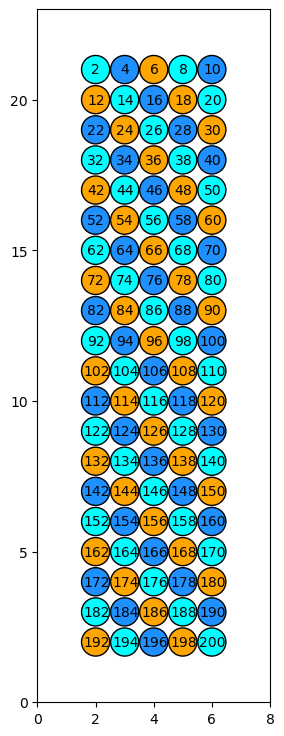

In [340]:
from matplotlib import pyplot as plt
import numpy as np


def make_nums (nx,ny,step=1,num_min=1,num_max=None):
    """
    Given nx and ny (column width and number of rows),
    as as well as step-size, return the numbers to be placed on the number grid
    as a flattened array.
    
    In principle the number grid shape and the numbers painted on
    it are independent.

    """
    if num_max is None:
        num_max=step*nx*ny
    nums = np.arange(num_max,num_min-1,-step)
    # Reorder rows of ny by nx array to reflect iteration order
    # We will go from bottom to top
    nums = nums.reshape(ny,nx)[list(range(ny-1,-1,-1)),:]
    # flatten array and reverse flattened array
    return nums.flatten()[::-1]

#colors = np.array(["magenta","orange","goldenrod","dodgerblue","aqua"])
#colors = np.array(["orange","goldenrod","dodgerblue","aqua"])
colors = np.array(["orange","dodgerblue","aqua"])
def make_num_colors (nums,colors=colors):
    """
    Apply colors according to modulus.  Modulus in force
    determined by the number of colkors passed in.
    """
    a = nums%len(colors)
    return colors[a]


def adjust_xoffset (num):
    """
    The more digits in the number,
    the more negative the x-offset
    """
    return -9 if num > 99 else -6 if num > 9 else -3



#nx, ny,step = (4, 20, 1)
nx, ny, step = (5, 20,2)
num_max = step*nx*ny
nums = make_nums(nx,ny,num_max=num_max,step=step)

# len(colors) is the modulus

num_colors = make_num_colors (nums,colors=colors)

left, right = 2, nx+2
bottom, top = 2, ny+2
pointsize=410

x = np.arange(left, right, 1)
y = np.arange(bottom, top, 1)
xv, yv = np.meshgrid(x, y)

xp,yp = xv.flatten(),yv.flatten()

##  Plotting stuff 
fig,ax = plt.subplots(1,1, figsize=(3,9))
ax.set_xlim(left-2,right+1)
ax.set_ylim(bottom-2,top+1)

ax.scatter(xp,yp,s=pointsize,c=num_colors,edgecolors="k")
for i in range(len(xp)):
    num = nums[i] # get_n (i,maxval,nx)
    xtext = adjust_xoffset (num)
    ax.annotate(f"{num}", xy=(xp[i],yp[i]),xytext=(xtext,-3),textcoords="offset points",
               )

## Version 2

Just roll your own xvals and yvals (which specify  the coordinates of the integers to
be plotted).  Apply the two-place function `eff` to the resulting `xvs` and `yvs` arrays to produce
 `zvs`.

You still have to reverse the order of the rows 

In [18]:
eff(1,1)

7

In [15]:
xv[:22],ny-yv[:22],zv[:22]

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19,  0,  1]),
 array([ 1,  6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 81,
        86, 91, 96,  2,  7]))

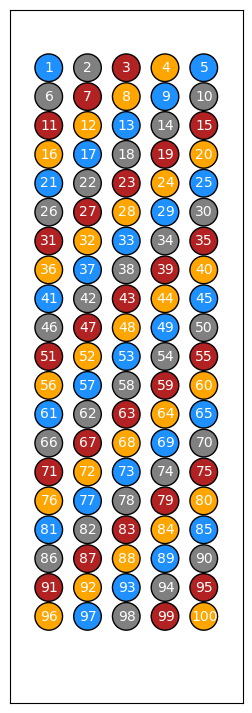

In [27]:
from matplotlib import pyplot as plt
import numpy as np

#colors = np.array(["magenta","orange","goldenrod","dodgerblue","firebrick"])
# Aqua shd be avoided with white fontcolor
#colors = np.array(["orange","goldenrod","dodgerblue","aqua"])
colors = np.array(["orange","dodgerblue","gray","firebrick"])
#colors = np.array(["orange","dodgerblue","aqua"])

def make_num_colors (nums,colors=colors):
    """
    Apply colors according to rersidue class.  Modulus in force
    determined by the number of colors passed in.
    """
    a = nums%len(colors)
    return colors[a]


nx, ny, step = (5, 20,1)
#nx, ny, step = (3, 20,2)
#nx, ny, step = (6, 20,2)
#Colors aligned with cols
#nx, ny, step = (4, 20,2)

def eff (j,i,c=nx,step=step):
    """
    xv, yv are oriented in natural Cartesian
    order: x is left to right, y up and down.
    So a fixed x specifies a column of values
    on the cartesian plane.  Sequencing: x is 0 while we process
    all the ys in col 0:  0,..., yx; then then we increment x by 1 and
    process all the ys in col 1: 0,..., yx; etc. The zvals 
    on the other hand need to be ordered left to
    right.  In the simplest case z |-> 1,2,... N.
    These two things taken together
    mean that the the 2nd zval, for example, is not the
    2nd integer processed.  It is the (yx+1)-th.
    Hence to compute n so as to know which
    zval we are computing, n = yval*c + xval.
    Hence param {j} represents xvals and
    param {i} y vals.
    """
    n = i*c + j
    return 1 + n*step

def adjust_xoffset (num):
    """
    The more digits in the number,
    the more negative the x-offset
    """
    return -9 if num > 99 else (-6 if num > 9 else -3)


xv, yv = zip(*[(i,j) for i in range(nx) for j in range(ny)])
xv, yv = np.array(xv), np.array(yv)
#  Compute the z-values as a function of the coords
zv = eff(xv,yv)
# reverse the row order, so that the integer in top left corner is 1.
yv = ny - yv

# Identify residue classes by color.
zcolors = make_num_colors (zv,colors=colors)

#############################################################
#
##  Plotting stuff 
#
#############################################################

# visually twiddled fudge factor
inc = -1
# nx is visually the row width; use for visual right border
left, right = inc, nx+inc
bottom, top = 0, ny
pointsize = 395

# figsize is width x height; roughly controlled by
# nx to ny ratio
fig,ax = plt.subplots(1,1, figsize=(3,9))
ax.set_xlim(left,right+1)
ax.set_ylim(bottom-2,top+2)
ax.scatter(xv,yv,s=pointsize,c=zcolors,edgecolors="k")

# Removes ticks and tick labels
ax.tick_params(axis='both', bottom=False, top=False, left=False, right=False, 
               labelbottom=False, labelleft=False) 


#############################################################
# index a particular reference point for debugging
ixx,debug = 1,False
if debug:
    # Blacken the reference point
    ax.scatter([xv[ixx]],[yv[ixx]],s=pointsize,c="k")
#############################################################

#############################################################
#
# Annotate the scatterplot with the number labels (from zv)
#
#############################################################

for i,num in enumerate(zv):
    if debug and i == ixx:
        print(i, zval, eff(xv[i],yv[i]), xv[i], yv[i])
    xtext = adjust_xoffset (num)
    ax.annotate(f"{num}", xy=(xv[i],yv[i]),xytext=(xtext,-3),textcoords="offset points",
                color="white" # fontcolor
               )